# Benchmark grid — model comparison across the test problems

The 4 defined mixed-variable test problems × 4 surrogate models (Standard LVGP, Heteroscedastic LVGP,
Separate GP, Categorical-kernel GP), all sharing the same SLHD initial design, acquisitions and sweep.
Reads `results/<function>/<model>/<acq>/nrep<NN>/seed<NN>.{npz,mat}` (python + matlab engines).

This generalizes the single-problem plots from `previous_ver/compare_methods.ipynb`: every view below is
**faceted over the test problems**, so it works for 1 or for all of them as the sweep fills in.

**Kernel: ml_gp_env.**

In [29]:
import warnings; warnings.filterwarnings("ignore")
import sys, os; sys.path.insert(0, os.path.abspath('..'))
import numpy as np, matplotlib.pyplot as plt
from utils import problems as P
from utils.results import (GridResults, facet, heatmaps_by_function, final_regret_table,
                           coverage, runtime_table,
                           regret_heatmap,
                           problem_report, all_problem_reports, acquisition_facet, latent_space,
                           acquisition_tables, acquisition_ranking,
                           method_tables, method_ranking, method_acq_leaderboard,
                           style_best, style_best_combined, export_comparison_tables,
                           acq_method_regret_table, acq_method_table,
                           acq_method_heatmap, export_acq_method_excel,
                           export_latex_tables,
                           seed_boxplot, ecdf, head_to_head)

grid = GridResults.load('../results')
print('functions:', grid.functions())
print('models   :', grid.models())
print('cells    :', len(grid.runs))

ImportError: cannot import name 'seed_boxplot' from 'utils.results' (/data/zhq7531/IDEAL/hetero_lvgp/benchmark/utils/results.py)

## The toggles

`GROUND_TRUTH` — how the **incumbent** (the "best design so far") is chosen, and what σ² means:

| | `True` | `False` |
|---|---|---|
| incumbent | argmin of the **noise-free** f | argmin of the **observed** replicate mean |
| σ² | the **true** noise variance σ(x,ℓ)² there | the **sample** variance of the replicates there |

This matters. The observed mean can dip *below* the true optimum f\* purely from noise (on branin,
`noisy_best = −3.16` against `f* = 0.465`), which makes a noisy "regret" look negative. `GROUND_TRUTH = True`
is the honest convergence measure; `False` shows what the optimizer actually saw.

`LOG_SCALE` applies to the regret and σ² convergence panels (not the value plot, which needs a linear axis
to show the f\* line).

In [ ]:
GROUND_TRUTH = True         # <-- incumbent & sigma^2 by the noise-free f (see table above)
LOG_SCALE    = True         # <-- log y-axis on the regret / sigma^2 convergence panels
CENTER       = 'mean'       # <-- 'mean' (± s.e.) or 'median' (± IQR) on the convergence bands
NOISE_AWARE_ONLY = True    # <-- per-acquisition facet: False = all 6 acqs, True = only HAEI/ANPEI/RAHBO
ACF, PARAM   = 'ei', float('nan')
N_REP        = 10           # replicates per design point: the sweep runs 3 and 10
FUNCS        = grid.functions()          # or e.g. ['branin_hetero', 'ackley_2d']
print(f'{len(FUNCS)} problems: {FUNCS}')


4 problems: ['ackley_2d', 'branin_hetero', 'griewank_2d', 'sixhump_camel']


## What the plots are averaging over
The sweep is long-running, so check the seed count behind each curve before reading too much into it.
`0` means that cell has not been computed yet.

In [ ]:
coverage(grid, n_rep=N_REP)

model                       Categorical kernel  Heteroscedastic LVGP  \
function      acq                                                      
ackley_2d     ANPEI(β=0.8)                  30                    30   
              EI                            30                    30   
              HAEI(γ=0.5)                   30                    30   
              LCB                           30                    30   
              PI                            30                    30   
              RAHBO(α=0.5)                  30                    30   
branin_hetero ANPEI(β=0.8)                  30                    30   
              EI                            30                    30   
              HAEI(γ=0.5)                   30                    30   
              LCB                           30                    30   
              PI                            30                    30   
              RAHBO(α=0.5)                  30                    30   
griewank_2d   ANPEI(β=0.8)                  30                    30   
              EI                            30                    30   
              HAEI(γ=0.5)                   30                    30   
              LCB                           30                    30   
              PI                            30                    30   
              RAHBO(α=0.5)                  30                    30   
sixhump_camel ANPEI(β=0.8)                  30                    30   
              EI                            30                    30   
              HAEI(γ=0.5)                   30                    30   
              LCB                           30                    30   
              PI                            30                    30   
              RAHBO(α=0.5)                  30                    30   

model                       Separate GP  Standard LVGP  
function      acq                                       
ackley_2d     ANPEI(β=0.8)           30              0  
              EI                     30             30  
              HAEI(γ=0.5)            30              0  
              LCB                    30             30  
              PI                     30             30  
              RAHBO(α=0.5)           30              0  
branin_hetero ANPEI(β=0.8)           30              0  
              EI                     30             30  
              HAEI(γ=0.5)            30              0  
              LCB                    30             30  
              PI                     30             30  
              RAHBO(α=0.5)           30              0  
griewank_2d   ANPEI(β=0.8)           30              0  
              EI                     30             30  
              HAEI(γ=0.5)            30              0  
              LCB                    30             30  
              PI                     30             30  
              RAHBO(α=0.5)           30              0  
sixhump_camel ANPEI(β=0.8)           30              0  
              EI                     30             30  
              HAEI(γ=0.5)            30              0  
              LCB                    30             30  
              PI                     30             30  
              RAHBO(α=0.5)           30              0

## Convergence — REGRET (value − f\*)
One panel per problem, the 4 models overlaid: mean ± standard error over seeds. Lower is better.
With `GROUND_TRUTH = True` regret is guaranteed ≥ 0, so the log axis is meaningful.

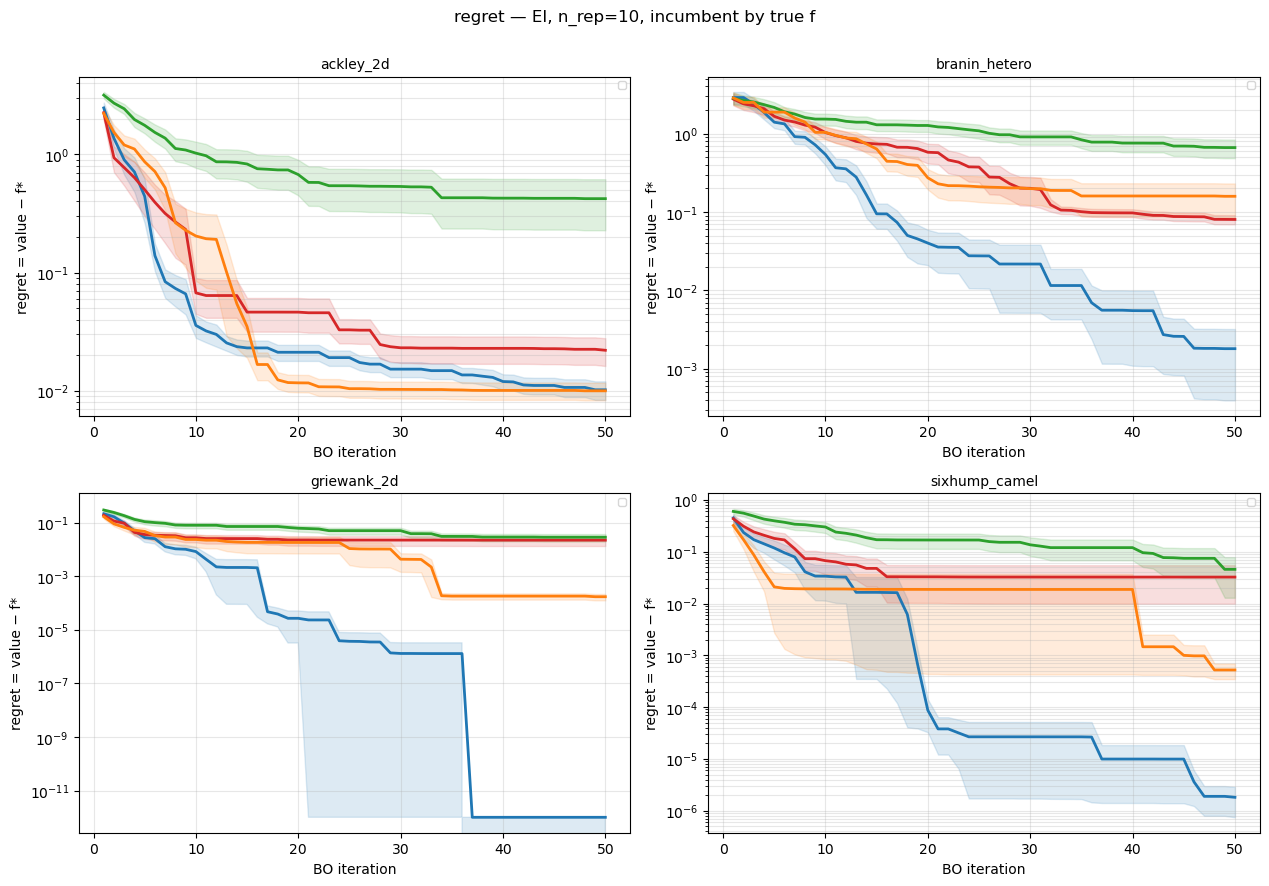

In [ ]:
facet(grid, 'regret', functions=FUNCS, acf=ACF, param=PARAM, n_rep=N_REP,
      ground_truth=GROUND_TRUTH, logy=LOG_SCALE, center=CENTER);

## Convergence — VALUE, with the true optimum f\* as a horizontal line
The same runs on a linear axis, showing how close each model's best design gets to f\* (dashed grey).

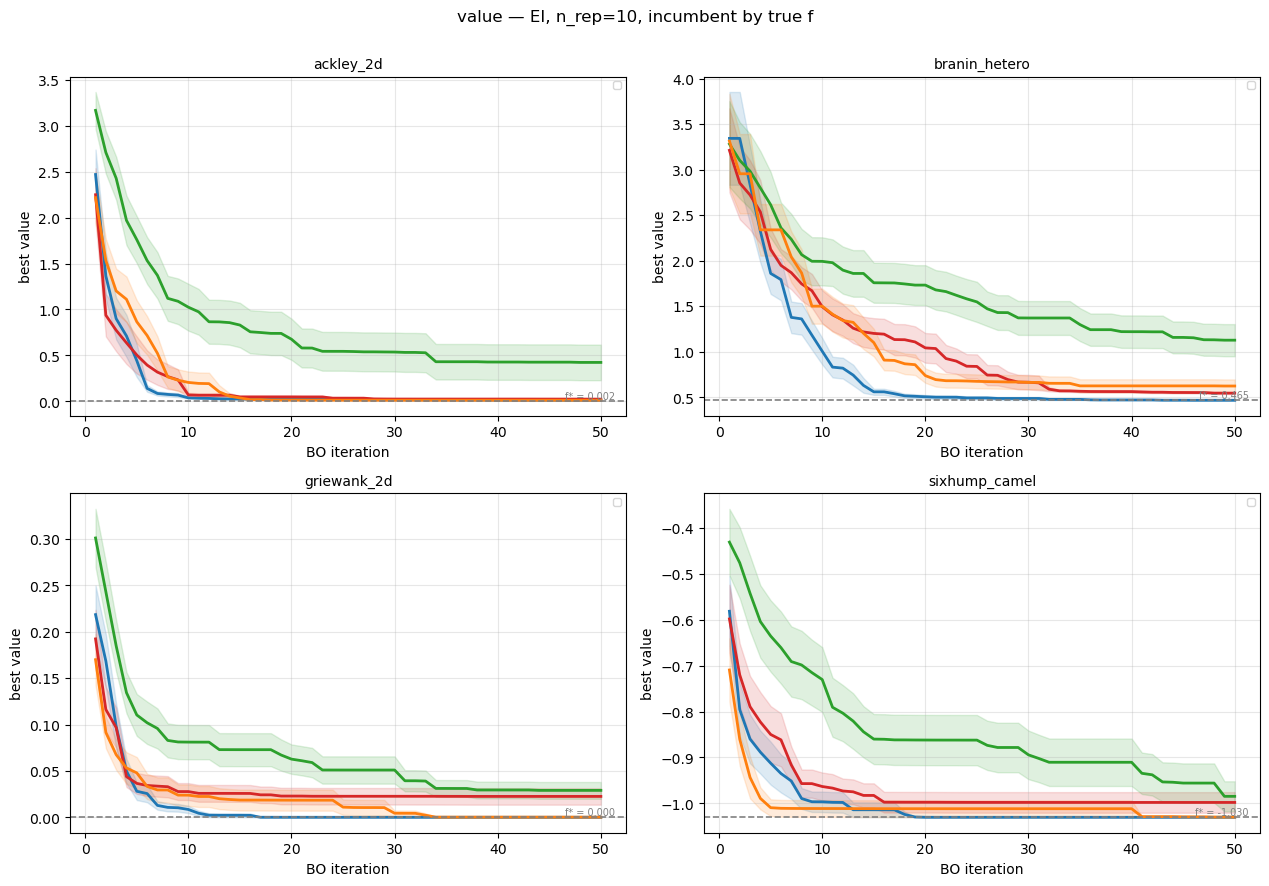

In [ ]:
facet(grid, 'value', functions=FUNCS, acf=ACF, param=PARAM, n_rep=N_REP,
      ground_truth=GROUND_TRUTH, logy=False, center=CENTER);

## Noise variance σ² at the incumbent best design
The heteroscedastic question: *does the model end up recommending a design that sits in a noisy region?*
A noise-aware model should settle on a **lower σ²** incumbent, all else equal. With `GROUND_TRUTH = True`
this is the true σ(x,ℓ)² at the incumbent — not an estimate.

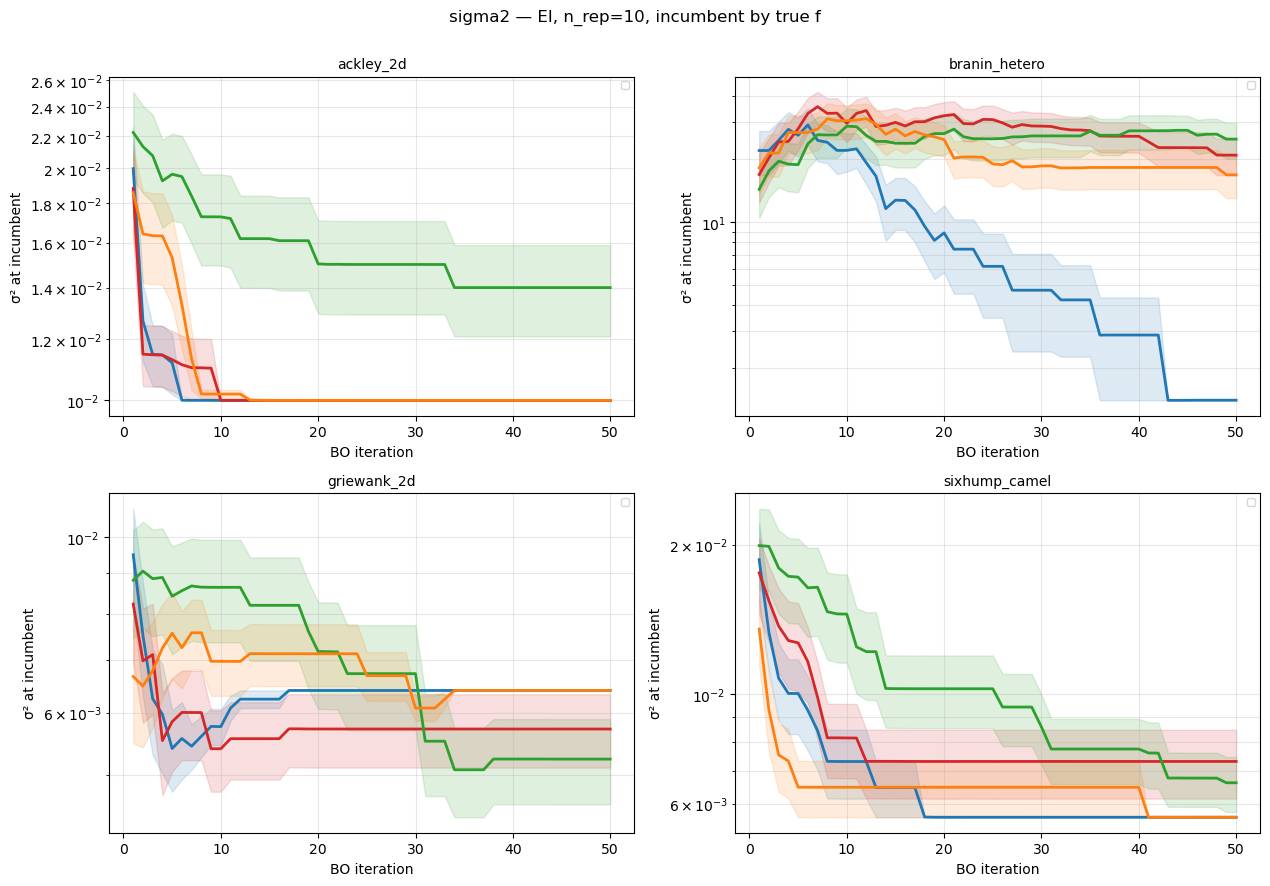

In [ ]:
facet(grid, 'sigma2', functions=FUNCS, acf=ACF, param=PARAM, n_rep=N_REP,
      ground_truth=GROUND_TRUTH, logy=LOG_SCALE, center=CENTER);

## Summary heatmaps — acquisition × model, one per problem
Final regret for every acquisition actually present in the results. Acquisition rows with no data anywhere
are dropped, so there are no blank bands. Darker = better (lower regret).

Note `standard_LVGP` only supports the noise-blind acquisitions (ei/lcb/pi) by construction, so its
haei/anpei/rahbo entries are legitimately empty.

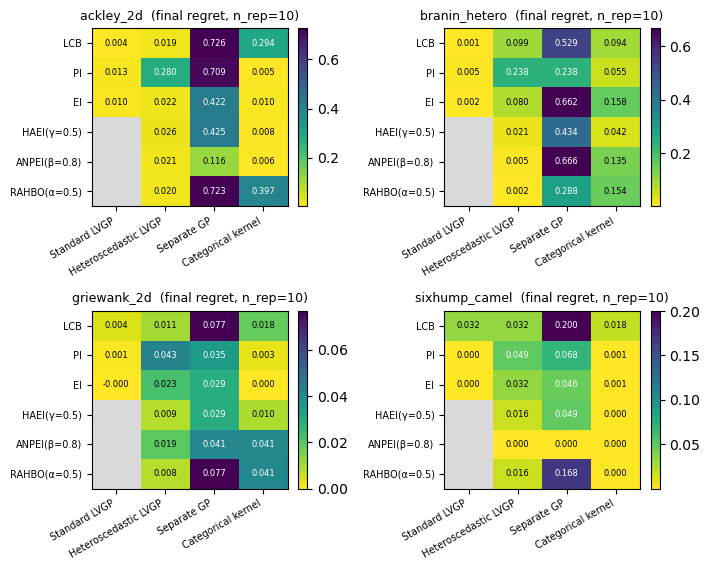

In [ ]:
heatmaps_by_function(grid, functions=FUNCS, n_rep=N_REP, ground_truth=GROUND_TRUTH);

### Consolidated regret heatmap — every model / acquisition / problem in one figure
Same numbers as the per-problem heatmaps above, but stacked into a single view so you can scan
model-vs-acquisition across all problems at once. **Each cell is annotated with the mean final regret.**

Since the problems span orders of magnitude in regret, a shared raw color scale would be useless, so
**color is normalized within each row**: green = best model for that (problem, acquisition), red = worst.
The printed number is the true regret. Grey = no data (e.g. Standard LVGP has no noise-aware acquisitions).
Set `normalize='func'` to make colors comparable across a problem's acquisitions instead of per-row.

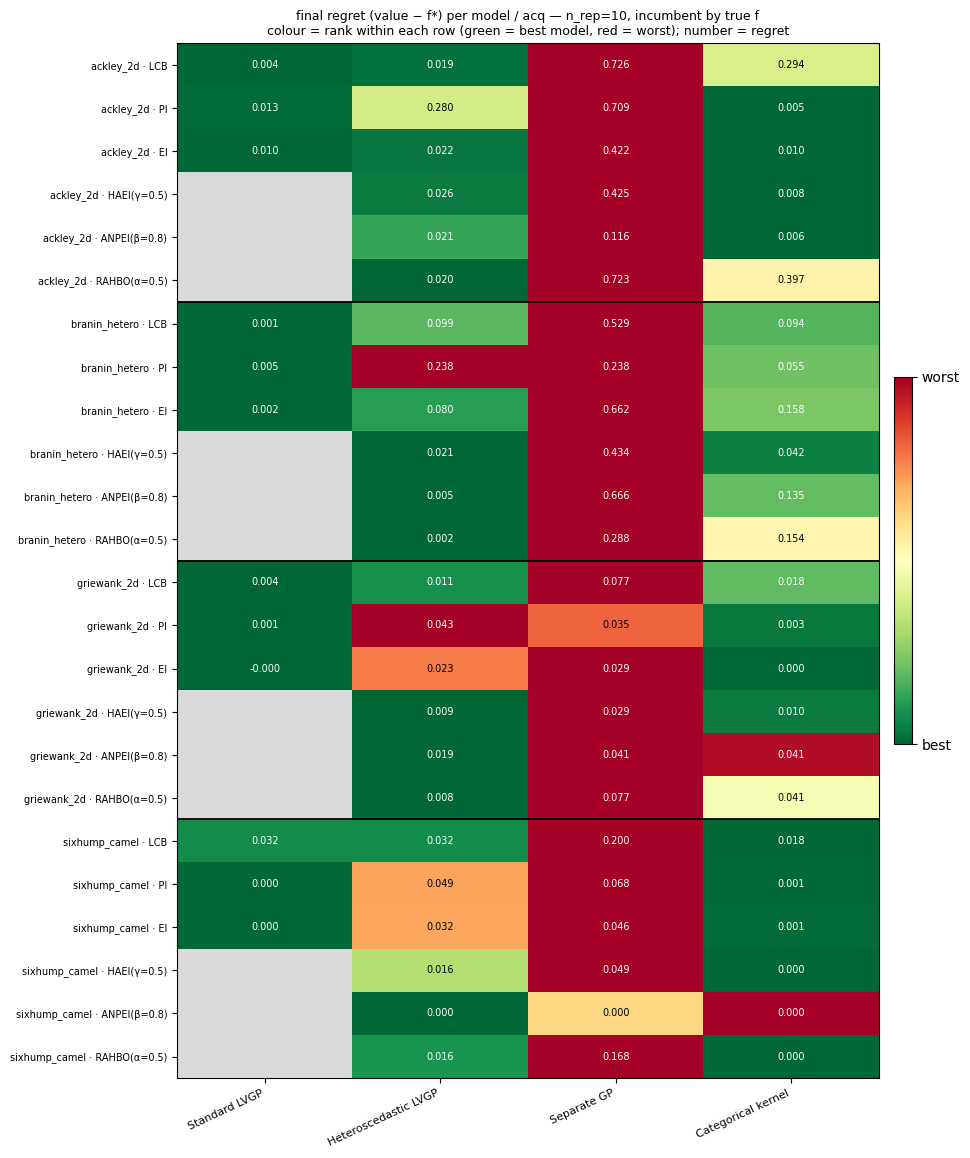

In [ ]:
regret_heatmap(grid, functions=FUNCS, n_rep=N_REP, ground_truth=GROUND_TRUTH, normalize='row');

## Final-regret summary table (problem × model)

In [ ]:
final_regret_table(grid, acf=ACF, param=PARAM, n_rep=N_REP)

,Categorical kernel,Heteroscedastic LVGP,Separate GP,Standard LVGP
ackley_2d,0.010 ± 0.009,0.022 ± 0.031,0.422 ± 1.044,0.010 ± 0.010
branin_hetero,0.158 ± 0.390,0.080 ± 0.058,0.662 ± 0.950,0.002 ± 0.008
griewank_2d,0.000 ± 0.000,0.023 ± 0.048,0.029 ± 0.049,-0.000 ± 0.000
sixhump_camel,0.001 ± 0.001,0.032 ± 0.121,0.046 ± 0.177,0.000 ± 0.000


## Cost — mean wall-clock seconds per cell
The two MATLAB LVGP models dominate the sweep's runtime; the python GPs are an order of magnitude cheaper.

model,Categorical kernel,Heteroscedastic LVGP,Separate GP,Standard LVGP
function,,,,
ackley_2d,73.4,410.9,18.8,396.5
branin_hetero,113.8,750.3,44.5,676.4
griewank_2d,54.2,312.7,17.7,312.6
sixhump_camel,58.2,312.9,20.5,305.3


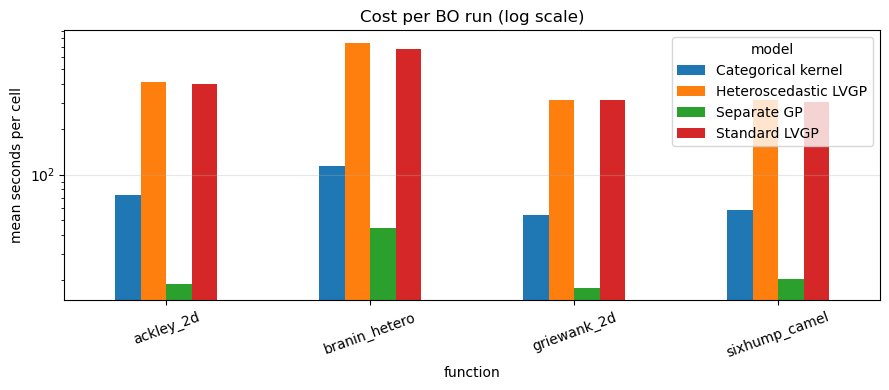

In [ ]:
rt = runtime_table(grid)
display(rt)
ax = rt.plot(kind='bar', figsize=(9, 4), rot=20)
ax.set_ylabel('mean seconds per cell'); ax.set_yscale('log')
ax.set_title('Cost per BO run (log scale)'); ax.grid(alpha=0.3, axis='y'); plt.tight_layout()

## Reading these plots

- **Regret vs σ²** are the two axes of the heteroscedastic trade-off. A model can win on regret while
  parking the incumbent in a high-noise region (bad if you must *deploy* that design), or vice versa.
- **`standard_LVGP` is noise-blind**: it never sees the replicate variance, so any advantage it shows on a
  noise-blind acquisition (ei/lcb/pi) is a fair comparison, but it cannot run haei/anpei/rahbo at all.
- Flip **`GROUND_TRUTH = False`** to see the optimizer's own view. Regret can go negative there — that is
  the noise, not a bug.
- Change `N_REP` between 3 and 10 to see how replicate count changes the variance estimate each model works
  from — the whole point of the heteroscedastic setup.

---
# Per-problem 

Everything above compares *across* problems. This section zooms into **one problem at a time** and
assesses every model / acquisition on it, with a consistent visual grammar so the encoding is learned once:

- **acquisition → colour**, **model → line style + marker** (in the panels that overlay both).

`problem_report(grid, function, ...)` produces two figures:

**overview** (6 panels)
1. the problem **landscape + initial DOE** — noise-free f(x1│level) per category, the true ±1σ noise band,
   the global optimum (★), and the shared SLHD design with its noisy replicates;
2. **regret** convergence (models, one acquisition);
3. **value** convergence with the f\* line;
4. **σ²** at the incumbent;
5. **all models × all acquisitions** on one regret axis (acq = colour, model = style);
6. **regret vs noise trade-off** — final regret against σ² at the incumbent; lower-left is the sweet spot.

**exploration** — the actual **sampling trajectory** of each model (x1 vs BO iteration, coloured by the
chosen categorical level, red line = the optimum's x1). This shows exploration-vs-exploitation and whether
a model locks onto the right category / x1.

`acf`/`param` fix the single acquisition used in panels 2–4 and the exploration figure; panels 5–6 sweep all
acquisitions.

> **How regret is computed here (and why it only steps *down*).**
> `regret(t) = [ best value among the first n_init + t sampled points ] − f*`, a **cumulative minimum**,
> so it is monotonic — it never rises. The visible steps are the best-so-far staircase (flat until a new
> best is sampled, then a drop), not noise. The `GROUND_TRUTH` toggle chooses what "best value" means:
> - **`True`** (default, and the case of interest here): the **noiseless** f(x, level) evaluated at each
>   sampled x — "sample the real value at the x locations, keep the best". Verified monotonic (0 up-jumps).
> - **`False`**: the **observed replicate mean** at each sampled x — "best across the mean".
>
> The only panel that legitimately rises and falls is **σ² at the incumbent** — that is not a best-so-far
> quantity: as the incumbent design changes, the noise level there can go up or down.

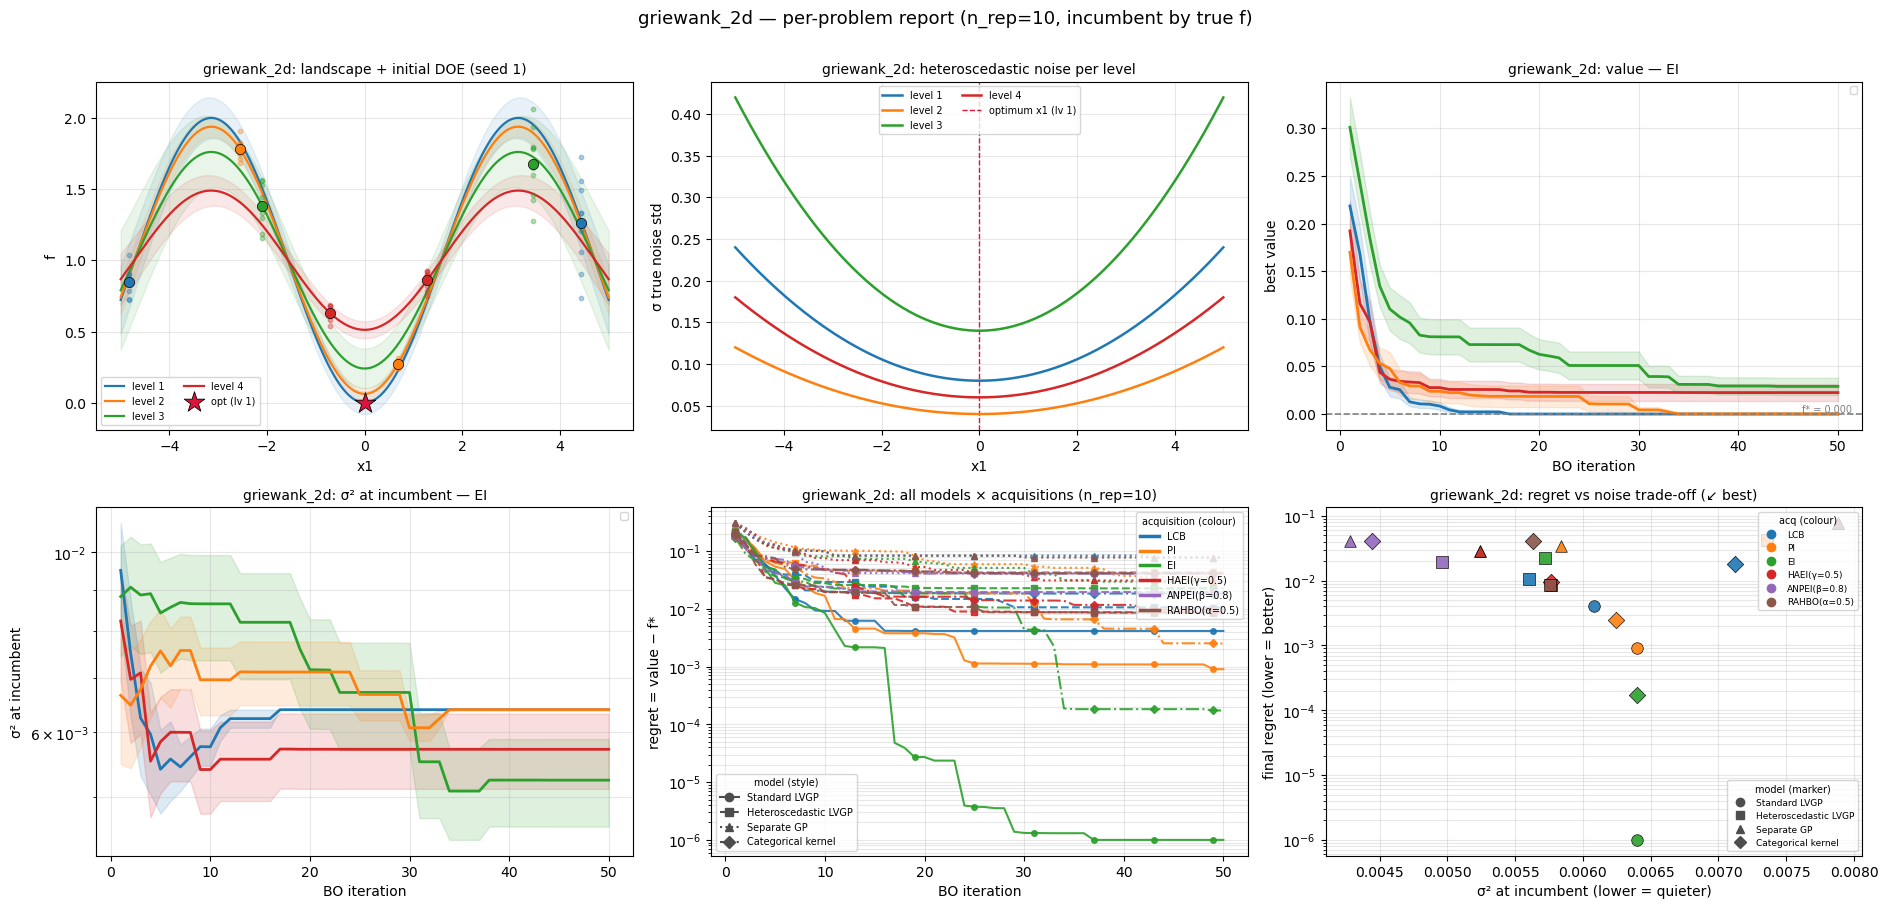

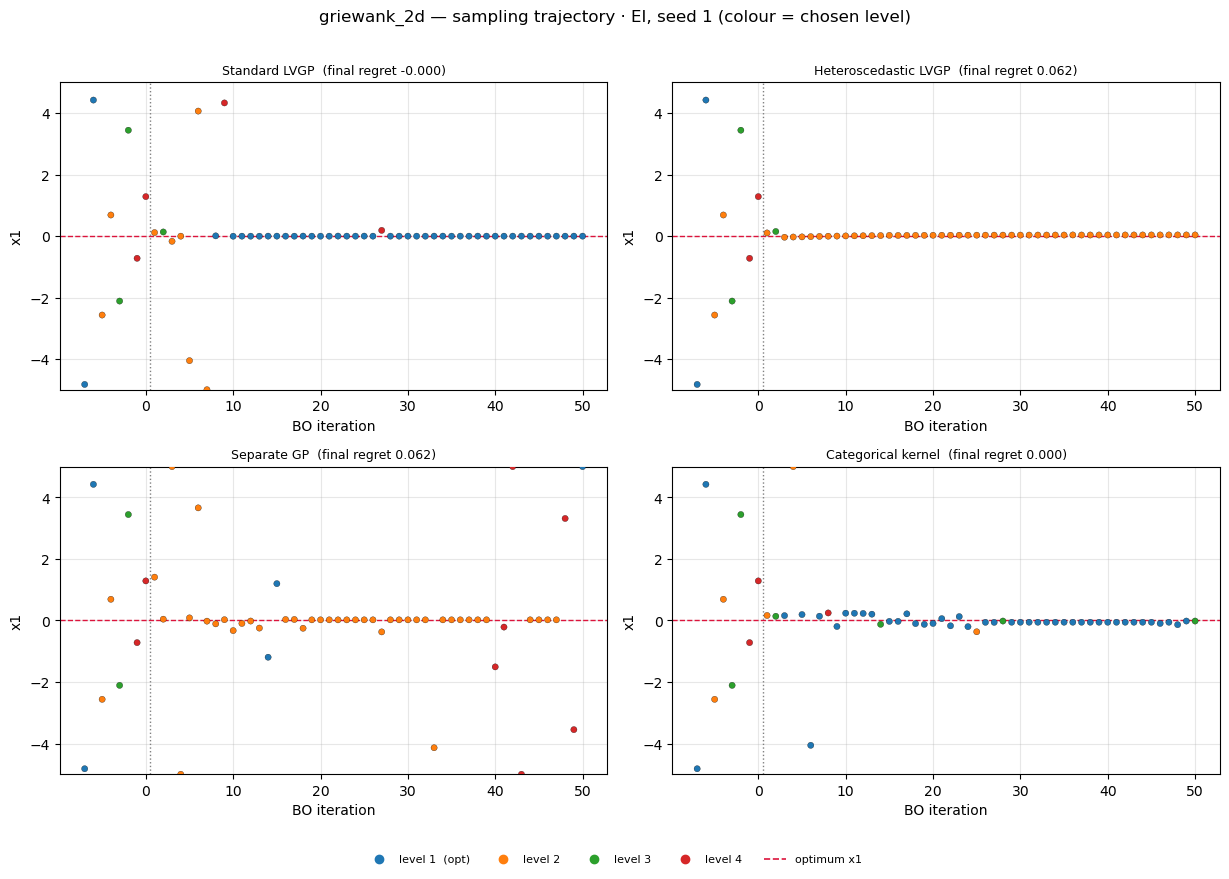

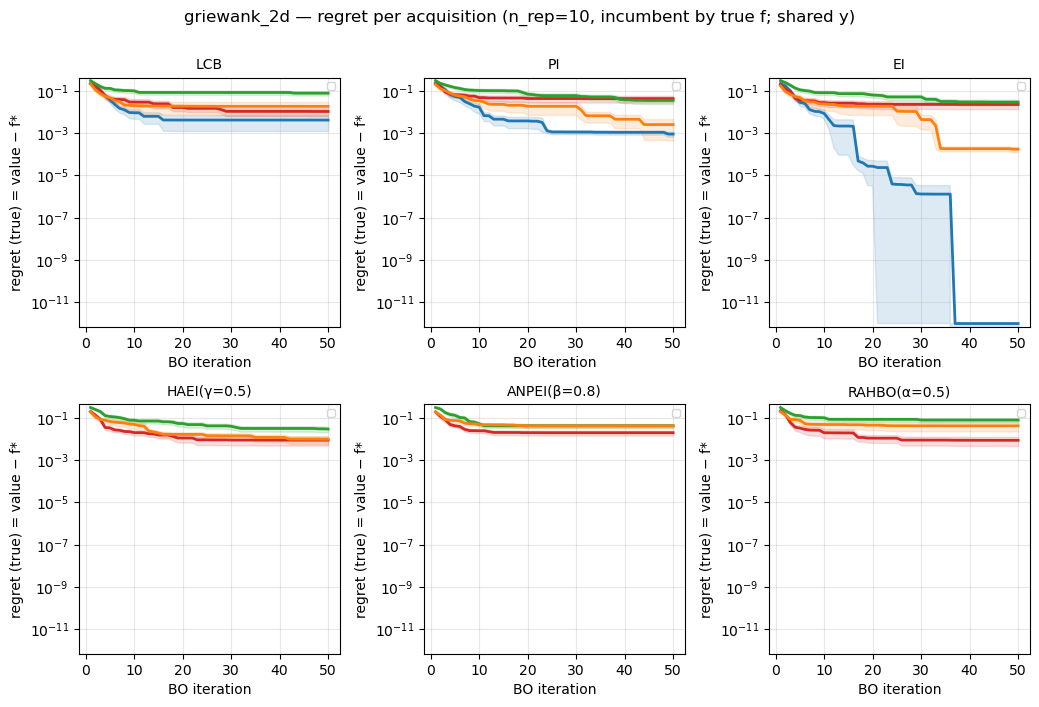

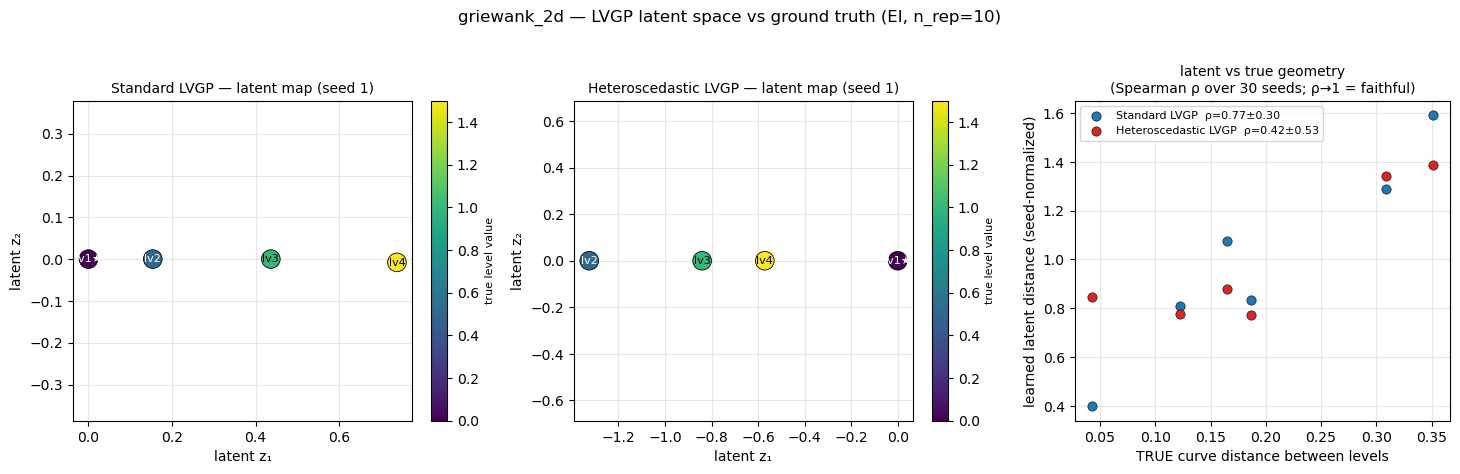

In [ ]:
FOCUS = FUNCS[2]           # <-- pick any problem to inspect inline; e.g. 'ackley_2d'
problem_report(grid, FOCUS, acf=ACF, param=PARAM, n_rep=N_REP,
               ground_truth=GROUND_TRUTH, seed=1, show=True);

### Regret per acquisition — one panel per acquisition, models overlaid (shared y-axis)
For the focus problem: a panel for each acquisition, overlaying every model's regret convergence
(mean ± s.e., colour = model). **All panels share one y-range**, so you can compare acquisitions directly
— e.g. which acquisition drives a given model lowest. The bottom row (haei/anpei/rahbo) has no Standard
LVGP line because that model is noise-blind. This is also saved per problem as `by_acquisition.png`.

> Set `NOISE_AWARE_ONLY = True` in the toggles cell to show only the noise-aware acquisitions (HAEI, ANPEI, RAHBO) instead of all 6.


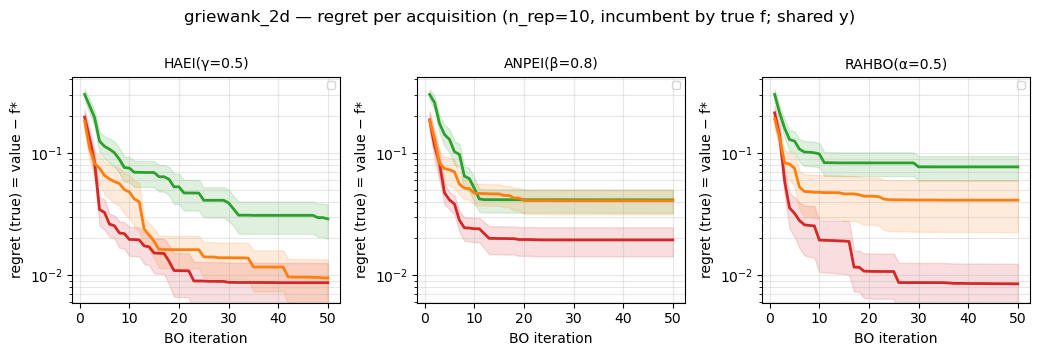

In [ ]:
acquisition_facet(grid, FOCUS, n_rep=N_REP, ground_truth=GROUND_TRUTH,
                  share_y=True, noise_aware_only=NOISE_AWARE_ONLY, center=CENTER);


### LVGP latent space vs ground truth
LVGP maps each categorical level to a 2-D latent point **z** — levels that behave similarly under the
true objective should land close together. Only the LVGP models expose this (`hyper.z`); the python GPs
have no such embedding.

- **Latent map** (one panel per LVGP model, one seed): each level's learned z, annotated (★ = optimal
  level), coloured by its **true underlying value** (`cat_values`). A smooth colour gradient means the
  embedding recovered the true ordering.
- **Recovery panel** (pooled over all seeds): a **rank–rank** plot of the learned latent distance vs the
  **true** distance between level pairs (RMS gap between their noise-free curves). The LVGP embedding is
  identifiable only up to rotation/reflection/**scale**, so an isometry (y=x on raw distances) is *not* a
  meaningful target — only the *ordering* of distances is. On rank–rank axes the **dashed diagonal is
  exactly perfect fidelity (Spearman ρ=1)**: points on it = pairs ordered correctly, points off it = pairs
  the embedding got out of order. Saved per problem as `latent_space.png`.

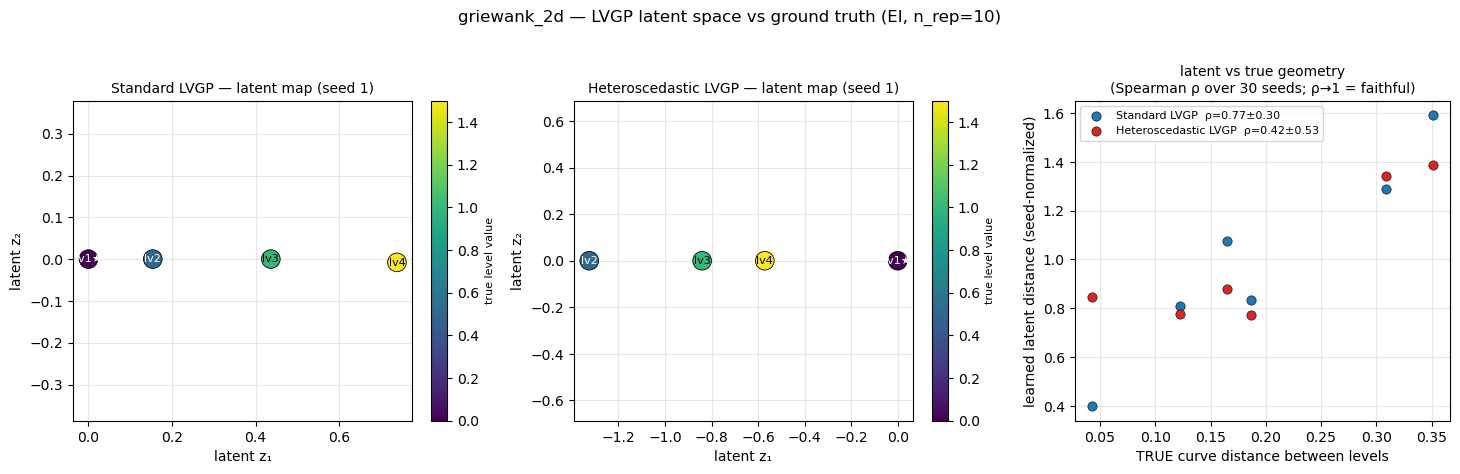

In [ ]:
latent_space(grid, FOCUS, acf=ACF, param=PARAM, n_rep=N_REP, seed=1);

### Generate the same report for **every** problem → `plots/<problem>/`
Writes `overview.png` + `exploration.png` under `notebooks/plots/<problem>/` for each test problem, so you
have them as files without cluttering the notebook. `show=False` keeps the batch output clean.

In [ ]:
all_problem_reports(grid, functions=FUNCS, save_root='plots',
                    acf=ACF, param=PARAM, n_rep=N_REP, ground_truth=GROUND_TRUTH,
                    seed=1, noise_aware_only=True);


  wrote plots/ackley_2d/overview.png + exploration.png + by_acquisition.png + latent_space.png


  wrote plots/branin_hetero/overview.png + exploration.png + by_acquisition.png + latent_space.png


  wrote plots/griewank_2d/overview.png + exploration.png + by_acquisition.png + latent_space.png


  wrote plots/sixhump_camel/overview.png + exploration.png + by_acquisition.png + latent_space.png


---
# Acquisition-function comparison

Comparing the 6 acquisitions across the 4 problems. Two tables:

**Table 1 — per-problem detail (fixed model).** For one model that supports all 6 acquisitions (default
`heter_LVGP`, the noise-aware flagship), the final **regret** (true = best noiseless value − f\*) and the
final **noisy best value** (the best observed replicate mean — what the optimizer actually saw; it can dip
below f\* on noise), each as mean ± sd over 30 seeds. Fixing the model isolates the acquisition effect.

**Table 2 — the conclusive one.** Regret magnitudes differ by orders of magnitude across problems, so you
*cannot* average raw regret. This table uses **ranks**: within each (problem × model) cell the 6
acquisitions are ranked by mean regret (1 = best), then averaged over all 12 cells (4 problems × the 3
models that support all 6 acquisitions). Lower `mean_rank` = better overall; `wins` = # cells it was best.

In [ ]:
ACQ_MODEL = 'separate_gp'          # any model supporting all 6 acqs: heter_LVGP / separate_gp / categorical_kernel
R, N = acquisition_tables(grid, model=ACQ_MODEL, n_rep=N_REP, functions=FUNCS)
print(f'TABLE 1a — final REGRET (true value − f*) · {ACQ_MODEL} · n_rep={N_REP} · mean ± sd over seeds')
display(style_best(R, {c: 'min' for c in FUNCS}))
print(f'TABLE 1b — final NOISY best value (best observed replicate mean) · {ACQ_MODEL} · n_rep={N_REP}')
display(style_best(N, {c: 'min' for c in FUNCS}))

TABLE 1a — final REGRET (true value − f*) · separate_gp · n_rep=10 · mean ± sd over seeds


,ackley_2d,branin_hetero,griewank_2d,sixhump_camel
Separate GP: acquisition,,,,
LCB,0.726 ± 1.3,0.529 ± 0.88,0.0769 ± 0.094,0.2 ± 0.33
PI,0.709 ± 1.3,0.238 ± 0.59,0.0349 ± 0.062,0.0684 ± 0.19
EI,0.422 ± 1,0.662 ± 0.95,0.029 ± 0.049,0.0457 ± 0.18
HAEI(γ=0.5),0.425 ± 1,0.434 ± 0.74,0.0288 ± 0.049,0.0486 ± 0.15
ANPEI(β=0.8),0.116 ± 0.55,0.666 ± 1.1,0.0413 ± 0.048,0.000237 ± 0.00041
RAHBO(α=0.5),0.723 ± 1.3,0.288 ± 0.78,0.0768 ± 0.094,0.168 ± 0.3


TABLE 1b — final NOISY best value (best observed replicate mean) · separate_gp · n_rep=10


,ackley_2d,branin_hetero,griewank_2d,sixhump_camel
Separate GP: acquisition,,,,
LCB,0.661 ± 1.3,-2.88 ± 2,0.0235 ± 0.082,-0.892 ± 0.31
PI,0.662 ± 1.2,-2.16 ± 1.9,-0.00703 ± 0.067,-1.01 ± 0.18
EI,0.375 ± 1,-2.98 ± 2,-0.0112 ± 0.055,-1.03 ± 0.16
HAEI(γ=0.5),0.368 ± 1,-2.7 ± 1.9,-0.00875 ± 0.058,-1.02 ± 0.14
ANPEI(β=0.8),0.0812 ± 0.55,0.359 ± 1.2,0.0155 ± 0.058,-1.07 ± 0.014
RAHBO(α=0.5),0.662 ± 1.3,-0.135 ± 1.1,0.0236 ± 0.084,-0.922 ± 0.28


### Table 2 (conclusive) — overall acquisition ranking by mean rank

In [ ]:
rank_df, ncells, models_used = acquisition_ranking(grid, n_rep=N_REP, functions=FUNCS)
print(f'mean rank over {ncells} (problem × model) cells · models: {models_used}')
print('lower mean_rank = better overall')
display(style_best(rank_df, {'mean_rank':'min','median_rank':'min','wins':'max'}))

mean rank over 12 (problem × model) cells · models: ['Heteroscedastic LVGP', 'Separate GP', 'Categorical kernel']
lower mean_rank = better overall


,mean_rank,median_rank,wins,n_cells
acquisition,,,,
HAEI(γ=0.5),2.750000,3.000000,2,12
ANPEI(β=0.8),2.920000,2.500000,3,12
RAHBO(α=0.5),3.420000,3.500000,3,12
EI,3.670000,4.000000,1,12
PI,3.830000,4.000000,2,12
LCB,4.420000,4.500000,1,12


### Full acquisition × method regret table — one table, two emphases
Every (acquisition × model) config on the 4 problems (final true regret, mean ± sd). Instead of two
separate tables: **bold** = best **model within each acquisition**; **green** = the single best
**(acquisition × model) combination** for that problem. Saved to Excel as one sheet per metric/n_rep.

In [ ]:
AM = acq_method_regret_table(grid, n_rep=N_REP, functions=FUNCS)
# ONE table: BOLD = best model for each acquisition · GREEN = best (acq × model) combo per problem
style_best_combined(AM, {c: 'min' for c in FUNCS}, group_level='acquisition')


### Same combined table for the **NOISE** (σ² at the incumbent — lower is better)
Same emphasis: **bold** = best model per acquisition, **green** = best combo overall per problem.

In [ ]:
AMn = acq_method_table(grid, 'noise', n_rep=N_REP, functions=FUNCS, ground_truth=GROUND_TRUTH)
# same combined style for the NOISE metric (σ² at incumbent, lower = better)
style_best_combined(AMn, {c: 'min' for c in FUNCS}, group_level='acquisition')


### Heatmaps — every acquisition × method, coloured per problem (green = best)
The same grids as heatmaps: colour is the rank within each problem column (scales differ across problems),
the number is the raw value. Regret first, then σ² at the incumbent.

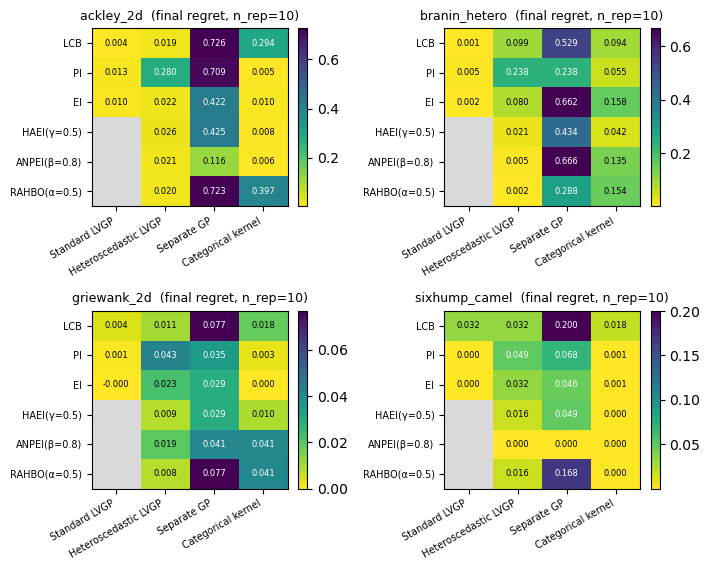

In [ ]:
acq_method_heatmap(grid, metric='regret', n_rep=N_REP, functions=FUNCS, ground_truth=GROUND_TRUTH);

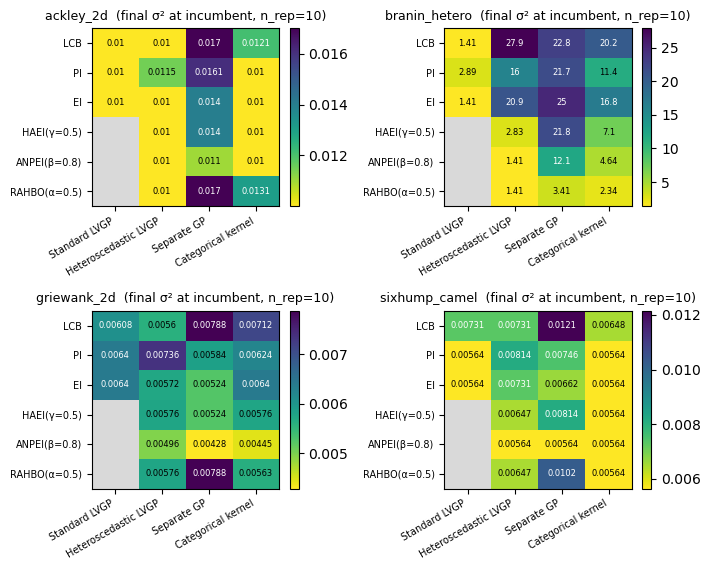

In [ ]:
acq_method_heatmap(grid, metric='noise', n_rep=N_REP, functions=FUNCS, ground_truth=GROUND_TRUTH);

### Robustness — mean-variance (RAHBO) metric
Plain regret rewards a great *mean* even in a loud region you couldn't deploy. RAHBO
(Makarova et al., NeurIPS 2021) instead scores the **mean-variance** objective
$\mathrm{MV}(x,\ell)=f(x,\ell)+\alpha\,\sigma^2(x,\ell)$ (lower = better) — low mean **and** low noise.
We can compute the *true* MV-regret exactly, since the true $f$ and $\sigma$ at every sampled point are
stored. `MV*` is the true robust optimum; `α` is the risk-aversion knob (`results.MV_ALPHA`, default 1).

Same combined highlighting; heatmap below. Note: MV amplifies the noise-aware acquisitions' advantage,
but at the **method** level plain LVGP can still win where the mean-optimum is already quiet (only branin,
with high noise at its optimum, flips to a noise-aware method).

In [ ]:
AMmv = acq_method_table(grid, 'mv', n_rep=N_REP, functions=FUNCS, ground_truth=GROUND_TRUTH)
style_best_combined(AMmv, {c: 'min' for c in FUNCS}, group_level='acquisition')

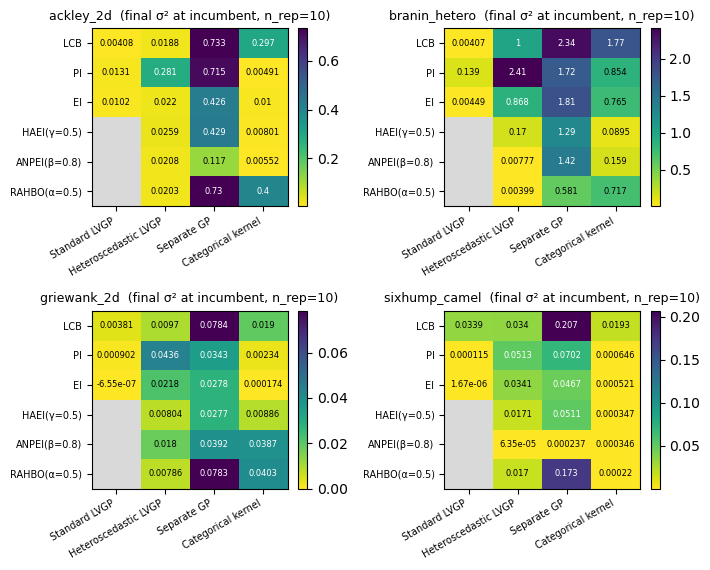

In [ ]:
acq_method_heatmap(grid, metric='mv', n_rep=N_REP, functions=FUNCS, ground_truth=GROUND_TRUTH);

---
### Distribution across seeds — why `mean ± sd` can mislead
Every table above is a **summary**. On heavy-tailed BO regret that can invert the conclusion. Concrete
case: on Branin, `Heter LVGP + RAHBO` and `Standard LVGP + LCB` have **the same mean MV-regret (~0.0040)**
— they look tied. They are not:

- **median:** RAHBO **0.00023** vs Standard LVGP **0.0035** → RAHBO is typically **~15× more robust**
  (Mann-Whitney p = 1.8e-4, a real difference).
- **worst seed:** RAHBO **0.060** vs Standard LVGP **0.010** → RAHBO's worst case is **6× worse**.

So RAHBO is *usually much better but occasionally fails badly*, while Standard LVGP is *consistently
mediocre*. Those two effects cancel in the mean, which is why it reads as a tie. Use the three views below
(numbers, ECDF, boxplot) rather than the mean alone; and flip `CENTER='median'` to put IQR bands on the
convergence plots.

In [ ]:
nan = float('nan')
HEAD = [('standard_LVGP','lcb',nan), ('standard_LVGP','ei',nan),
        ('heter_LVGP','ei',nan), ('heter_LVGP','anpei',0.8), ('heter_LVGP','rahbo',0.5)]
# mean vs MEDIAN vs worst-case + rank test against the best-median config
head_to_head(grid, 'branin_hetero', HEAD, metric='mv', n_rep=N_REP, ground_truth=GROUND_TRUTH)

,mean,median,iqr,worst,n,p_vs_best_median
config,,,,,,
Heteroscedastic LVGP + RAHBO(α=0.5),0.003987,0.000231,0.001577,0.060477,30,—
Heteroscedastic LVGP + ANPEI(β=0.8),0.007768,0.001384,0.006537,0.122193,30,1.3e-01
Standard LVGP + LCB,0.004072,0.003524,0.005671,0.010149,30,1.8e-04
Standard LVGP + EI,0.004493,0.004555,0.005703,0.014296,30,1.3e-04
Heteroscedastic LVGP + EI,0.868299,0.097411,0.825346,7.233644,30,1.5e-09


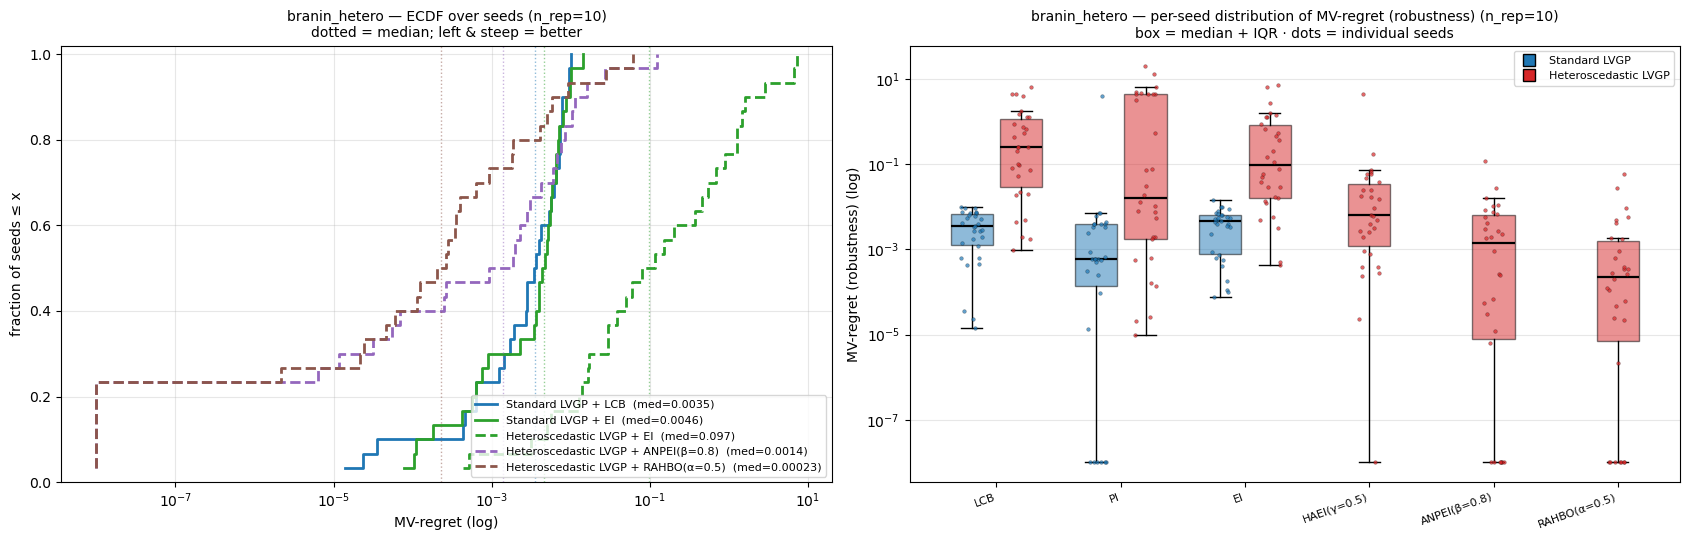

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(17, 5.5))
ecdf(grid, 'branin_hetero', HEAD, metric='mv', n_rep=N_REP, ground_truth=GROUND_TRUTH, ax=axes[0])
seed_boxplot(grid, 'branin_hetero', metric='mv', n_rep=N_REP, ground_truth=GROUND_TRUTH,
             models=['standard_LVGP','heter_LVGP'], ax=axes[1])
fig.tight_layout()

**Reading them.** The **ECDF** is `P(metric ≤ x)`: a curve that rises *far left* is typically better; a
long flat tail on the right = occasional failures. RAHBO reaches the robust optimum on ~23% of seeds
(the leftmost jump) but trails a tail. The **boxplot** shows the same per-acquisition: the noise-aware
boxes (HAEI/ANPEI/RAHBO) sit far lower than the noise-blind ones, with wider whiskers.

### Export the full acquisition × method tables to a **separate** workbook
`acq_method_tables.xlsx` — 8 sheets: {regret, noise} × {n_rep 3, 10} × {best-per-acq, best-combo}
highlightings. (These are kept out of the main `comparison_tables.xlsx`.)

In [ ]:
xlsx2 = export_acq_method_excel(grid, path='acq_method_tables.xlsx',
                                n_reps=(3, 10), functions=FUNCS, ground_truth=GROUND_TRUTH)
print('wrote', xlsx2, '— 8 sheets (regret & noise · nrep 3 & 10 · two highlightings)')

wrote acq_method_tables.xlsx — 8 sheets (regret & noise · nrep 3 & 10 · two highlightings)


### LaTeX tables (paper-ready) → `latex/`
Writes the same four acquisition × method tables as booktabs LaTeX (bold = best per acquisition, green =
best combo), plus `latex/main.tex` you can compile to a PDF. `compile_pdf=True` runs pdflatex if present.

In [ ]:
tex_files = export_latex_tables(grid, out_dir='../latex', n_reps=(3, 10),
                                functions=FUNCS, ground_truth=GROUND_TRUTH, compile_pdf=True)
print('wrote:'); [print('  ', f) for f in tex_files]

wrote:
   ../latex/regret_nrep03.tex
   ../latex/regret_nrep10.tex
   ../latex/noise_nrep03.tex
   ../latex/noise_nrep10.tex
   ../latex/mv_nrep03.tex
   ../latex/mv_nrep10.tex
   ../latex/main.tex
   ../latex/main.pdf


[None, None, None, None, None, None, None, None]

---
# Method (surrogate) comparison

Same idea as the acquisition tables, for the 4 surrogate models. **Fairness note:** `standard_LVGP` only
runs the 3 noise-blind acquisitions, and `heter_LVGP`'s edge needs a noise-aware one — so a single fixed
acquisition can't rank the models fairly. The conclusive table therefore reports two angles.

**Table 1 — per-problem detail** at a shared acquisition (EI, which all 4 models run): final regret and
noisy best value, mean ± sd over seeds.

**Table 2 — conclusive model ranking**, from two fair angles (regret can't be averaged across problems →
ranks):
- `mean_rank_bestacq`: each model uses its **own best acquisition** per problem, then the 4 models are
  ranked — "each model at its best". This is the fair view for `heter_LVGP`.
- `mean_rank_blind`: all 4 models on the **shared noise-blind** acquisitions only (apples-to-apples).

**Table 3 — the combined leaderboard**: every (model × acquisition) configuration ranked within each
problem, averaged. Top row = the single best configuration overall. This pools *both* factors.

In [ ]:
Rm, Nm = method_tables(grid, acf='ei', n_rep=N_REP, functions=FUNCS)
print(f'METHOD TABLE 1a — final REGRET · acq=EI · n_rep={N_REP} (all 4 models; EI is noise-blind)')
display(style_best(Rm, {c: 'min' for c in FUNCS}))
print(f'METHOD TABLE 1b — final NOISY best value · acq=EI · n_rep={N_REP}')
display(style_best(Nm, {c: 'min' for c in FUNCS}))

METHOD TABLE 1a — final REGRET · acq=EI · n_rep=10 (all 4 models; EI is noise-blind)


,ackley_2d,branin_hetero,griewank_2d,sixhump_camel
acq=EI: model,,,,
Standard LVGP,0.0102 ± 0.0098,0.00181 ± 0.0076,-6.54e-07 ± 4.2e-07,1.81e-06 ± 5.8e-06
Heteroscedastic LVGP,0.022 ± 0.031,0.0802 ± 0.058,0.0225 ± 0.048,0.0324 ± 0.12
Separate GP,0.422 ± 1,0.662 ± 0.95,0.029 ± 0.049,0.0457 ± 0.18
Categorical kernel,0.01 ± 0.0092,0.158 ± 0.39,0.000174 ± 0.00025,0.000521 ± 0.00094


METHOD TABLE 1b — final NOISY best value · acq=EI · n_rep=10


,ackley_2d,branin_hetero,griewank_2d,sixhump_camel
acq=EI: model,,,,
Standard LVGP,0.0265 ± 0.0095,0.372 ± 0.43,0.0113 ± 0.0036,-1.02 ± 0.0037
Heteroscedastic LVGP,0.0388 ± 0.031,0.486 ± 0.47,0.0327 ± 0.049,-0.986 ± 0.13
Separate GP,0.375 ± 1,-2.98 ± 2,-0.0112 ± 0.055,-1.03 ± 0.16
Categorical kernel,-0.0355 ± 0.025,-3.3 ± 1.5,-0.0427 ± 0.013,-1.07 ± 0.013


### Table 2 (conclusive) — model ranking, two fair angles

In [ ]:
mrank = method_ranking(grid, n_rep=N_REP, functions=FUNCS)
display(style_best(mrank, {'mean_rank_bestacq':'min','mean_rank_blind':'min','wins_bestacq':'max'}))

,mean_rank_bestacq,wins_bestacq,mean_rank_blind,usual_best_acq
model,,,,
Standard LVGP,1.000000,4,1.250000,LCB
Heteroscedastic LVGP,2.500000,0,2.830000,RAHBO(α=0.5)
Categorical kernel,2.500000,0,2.000000,PI
Separate GP,4.000000,0,3.920000,ANPEI(β=0.8)


### Table 3 (conclusive, both factors) — best (model × acquisition) configurations

In [ ]:
lb = method_acq_leaderboard(grid, n_rep=N_REP, functions=FUNCS)
print(f'combined leaderboard — mean rank of each config over {len(FUNCS)} problems (lower = better)')
display(style_best(lb.head(12), {'mean_rank':'min','best_rank':'min','wins':'max'}))

combined leaderboard — mean rank of each config over 4 problems (lower = better)


> **Reading these — regret is not the whole story.** These tables rank by **regret** (finding the
> mean-optimum). By that metric the simple **Standard LVGP with a noise-blind acquisition dominates** on
> these 4 problems — the heteroscedastic machinery doesn't pay off for pure optimization here. But
> `RAHBO`/`ANPEI` optimize a **risk-averse** objective (mean *and* variance), so judging them by mean
> regret alone undersells them: see the **σ² at the incumbent** panels — the noise-aware methods settle on
> **quieter** designs, which is their actual goal. So "best" depends on whether you want the lowest-*mean*
> point or a low-*noise* point you can deploy.

### Export all tables to Excel
Writes every acquisition/method/leaderboard table to one formatted workbook (`comparison_tables.xlsx`):
7 sheets, the **best cell in each column bold + green-highlighted**, headers frozen, columns auto-width.

In [ ]:
xlsx, _ = export_comparison_tables(grid, path='comparison_tables.xlsx',
                                   n_rep=N_REP, functions=FUNCS, acq_model=ACQ_MODEL)
print('wrote', xlsx, '— 7 sheets; best value per column is bold + highlighted')

wrote comparison_tables.xlsx — 7 sheets; best value per column is bold + highlighted
